<p align="center">
  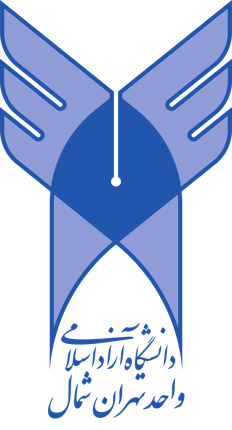
</p><br>

# **Brain Tumor Detection and Classification in MRI Using Hybrid ViT and GRU Model with Explainable AI**
### *Clinical Case Study: Southern Bangladesh Region*

---

### **Project Overview**
This research implements an advanced deep learning framework designed to enhance diagnostic accuracy for brain tumors within the clinical landscape of **Southern Bangladesh**. Due to the proprietary nature of regional hospital data (**2023-BrTMHD**), this implementation utilizes the **Brain MRI Dataset for Tumor Detection and Analysis** as a high-fidelity proxy. The system is designed to provide not only high-accuracy classification but also clinical interpretability.

---

### **Research & Development Team**

* **Hesam Servati – حسام ثروتی - `404198788`**
* **Mohammad mahdi Nosrati – محمد مهدی نصرتی - `404188074`**
* **Amirali Mohammadi – امیرعلی محمد - `404224755`**

**Under the Supervision of:**
**Professor Maliheh Sabeti - دکتر ملیحه ثابتی** <br>`North Tehran Branch` | `Azad University`

---

### **Core Methodology & Architecture**
* **Data Source:** Brain MRI Dataset for Tumor Detection and Analysis (Kaggle).
* **Multi-Modal Inputs:** T1, T2, FLAIR, and DWI (Diffusion Weighted Imaging).

* **Hybrid Model Architecture:** * **Vision Transformer (ViT):** For capturing global spatial dependencies and intricate features within MRI slices.
    * **Gated Recurrent Unit (GRU):** To model sequential dependencies across different MRI modalities or volumetric slices.

* **Explainable AI (XAI):** * **SHAP & LIME:** To provide local and global feature importance.
    * **Attention Maps:** To visualize the specific regions of the brain the ViT focuses on for its predictions.

---

In [11]:
import kagglehub
import os
import shutil
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
!pip install torchinfo
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.cuda.amp import autocast, GradScaler
import torch.nn as nn
import torch.nn.functional as F
import gc
from sklearn.model_selection import KFold
import seaborn as sns
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
!pip install lime shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
# Import the Data Preprocessing functions from preprocessing.py file
import preprocessing
# Import the Model Implementation from model.py file
import model

print("All libraries are ready to use!")

All libraries are ready to use!


# Step 1: Data Collection
We download and import the data into the Files part here, so we can use that.

---

# Step 2: Data Preparation
## Step 2.1: Data Acquisition
The traditional **Data Acquisition** phase is bypassed because the dataset is imported via the `kagglehub` API directly in a structured `.mat` (MATLAB) format. Since the raw data is already organized into numerical matrices, no manual acquisition or restructuring is required. This automation ensures a seamless transition to the preprocessing pipeline while maintaining full reproducibility.
## Step 2.2: Dicom To JPG
The conversion from **DICOM to JPG** is intentionally skipped to ensure the highest diagnostic integrity for the model.
* **Preservation of Numerical Precision:** `.mat` files maintain the original 12-bit or 16-bit pixel intensities. Converting to JPG would compress this data into 8-bit, resulting in a loss of subtle clinical information.
* **Hybrid ViT-GRU Optimization:** The **Vision Transformer (ViT)** and **GRU** architectures perform better on high-fidelity tensors. By avoiding JPG compression artifacts, we provide the model with raw spatial and sequential features necessary for accurate tumor classification.

In [ ]:
# --- 1. CONFIGURATION ---
dataset_name = "akrashnoor/brain-tumor"
target_folder = "/content/Brain Tumor Dataset"
# This identifies the sub-path we want to keep
path_to_keep = "2 classes"

# --- 2. DOWNLOAD & COPY ---
download_path = kagglehub.dataset_download(dataset_name)
print(f"📍 Original download path: {download_path}")

if os.path.exists(target_folder):
    shutil.rmtree(target_folder)

# We define the exact source folder inside the downloaded files
source_path = os.path.join(download_path, path_to_keep)

# Copy ONLY the '2 classes' folder to your workspace
if os.path.exists(source_path):
    shutil.copytree(source_path, target_folder)
    print(f"✅ Successfully copied the '{path_to_keep}' folder to: {target_folder}")
else:
    print(f"❌ Error: Could not find '{path_to_keep}' in the download path.")

# --- 3. CLEANUP STEP: Ensure only images remain ---
valid_extensions = (".jpg", ".jpeg", ".png")
files_removed = 0

for root, dirs, files in os.walk(target_folder):
    for file in files:
        if not file.lower().endswith(valid_extensions):
            file_path = os.path.join(root, file)
            os.remove(file_path)
            files_removed += 1

# --- 4. FINAL VERIFICATION ---
print("\n📁 Final Binary Dataset Structure:")
for category in os.listdir(target_folder):
    cat_path = os.path.join(target_folder, category)
    if os.path.isdir(cat_path):
        num_files = len(os.listdir(cat_path))
        print(f"    📂 {category}/ ({num_files} images)")

Using Colab cache for faster access to the 'brain-tumor' dataset.
📍 Original download path: /kaggle/input/brain-tumor
✅ Successfully copied the '2 classes' folder to: /content/Brain Tumor Dataset

📁 Final Binary Dataset Structure:
    📂 yes/ (4159 images)
    📂 no/ (2024 images)


## Step 2.3: Data Labeling
In this step, we transformed raw, unstructured medical files into a labeled dataset ready for Machine Learning. Unlike standard image formats (like `JPG`), the Cheng Brain Tumor Dataset stores its classification labels inside the `.mat` file metadata.

### Process Overview


1.   **Metadata Extraction:** Used the h5py library to access the internal cjdata structure of each file.
2.   **Label Parsing:** Extracted the integer stored in the label field (1, 2, or 3).
3.   **Categorical Mapping:** Mapped these integers to their clinical tumor names:

      *   **1** → Meningioma
      *   **2** → Glioma
      *   **3** → Pituitary
      *   **0** → No Tumor (Included for pipeline compatibility)
4.  **Data Structuring:** Compiled all file paths and labels into a pandas DataFrame to serve as a master reference for the Training and Testing phases.

In [ ]:
# 1. Update Path to your new binary dataset folder
data_path = "/content/Brain Tumor Dataset"

# 2. Update types for Binary Classification
tumor_types = {
    "no": "No Tumor",
    "yes": "Tumor"
}

data_list = []
print("🏷️ Extracting labels from folder names...")

# Walk through the folder to find all .jpg files
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            # The category name is the name of the folder containing the file
            folder_name = os.path.basename(root)

            if folder_name in tumor_types:
                data_list.append({
                    "File_Name": file,
                    "File_Path": os.path.join(root, file),
                    "Label_ID": 1 if folder_name == "yes" else 0,
                    "Tumor_Type": tumor_types[folder_name]
                })

# Create DataFrame
df_labels = pd.DataFrame(data_list)

print(f"✅ Labeling Complete! Found {len(df_labels)} labeled images.")
print("\n--- Current Class Balance ---")
print(df_labels['Tumor_Type'].value_counts())

# Display the first 10 rows
df_labels.head(10)

🏷️ Extracting labels from folder names...
✅ Labeling Complete! Found 6183 labeled images.

--- Current Class Balance ---
Tumor_Type
Tumor       4159
No Tumor    2024
Name: count, dtype: int64


,File_Name,File_Path,Label_ID,Tumor_Type
0,Y (2826).JPG,/content/Brain Tumor Dataset/yes/Y (2826).JPG,1,Tumor
1,Y (2286).jpg,/content/Brain Tumor Dataset/yes/Y (2286).jpg,1,Tumor
2,Y (366).jpg,/content/Brain Tumor Dataset/yes/Y (366).jpg,1,Tumor
3,Y (1821).jpg,/content/Brain Tumor Dataset/yes/Y (1821).jpg,1,Tumor
4,Y (191).jpg,/content/Brain Tumor Dataset/yes/Y (191).jpg,1,Tumor
5,Y (2764).jpg,/content/Brain Tumor Dataset/yes/Y (2764).jpg,1,Tumor
6,Y (2961).jpg,/content/Brain Tumor Dataset/yes/Y (2961).jpg,1,Tumor
7,Y (2570).jpg,/content/Brain Tumor Dataset/yes/Y (2570).jpg,1,Tumor
8,Y (279).jpg,/content/Brain Tumor Dataset/yes/Y (279).jpg,1,Tumor
9,Y (436).jpg,/content/Brain Tumor Dataset/yes/Y (436).jpg,1,Tumor


## 2.4 Creating the Master Stack (Raw Data)
In this phase, we move from individual files to a unified numerical structure. We consolidate all raw MRI matrices into a single variable, `X_raw`, which acts as our central dataset. This approach follows the project's requirement for Noise Removal and Data Preprocessing steps.
*   **Handling Inhomogeneity:** Because medical datasets often contain scans of varying resolutions (e.g., 512x512 vs 256x256), we use `dtype=object`. This prevents a `ValueError` by allowing NumPy to store the matrices as a collection of independent objects rather than a rigid 3D cube.
*   **Data Integrity:** We skip normalization and resizing here to ensure that the Noise Removal (Step 6.1) filter operates on the original raw intensity values, preserving the maximum possible information for medical accuracy.
*   **Workflow Integration:** Consolidating files into a single array allows for significantly faster processing in subsequent cells, as we no longer need to perform slow I/O operations (opening and closing files) for every preprocessing step.

In [ ]:
# ==========================================
# 📦 STACK CREATION (Images & Labels)
# ==========================================
temp_images = []
temp_labels = []

print("\n⌛ Loading images and labels into Master Stack...")

# Use iterrows to keep them paired
for index, row in df_labels.iterrows():
    img = cv2.imread(row['File_Path'])
    if img is not None:
        temp_images.append(img)
        temp_labels.append(row['Label_ID'])

# Convert to NumPy
X_raw = np.array(temp_images, dtype=object)
y_labels = np.array(temp_labels)

print(f"✅ X_raw shape: {X_raw.shape} (Images)")
print(f"✅ y_labels shape: {y_labels.shape} (Targets)")


⌛ Loading images and labels into Master Stack...
✅ X_raw shape: (6183,) (Images)
✅ y_labels shape: (6183,) (Targets)


# Step 3: Data Preprocessing
## Step 3.1: Noise Removal (Gaussian Filtering)
In this step, we implement the noise reduction phase of the **Data Preparation** workflow. Instead of processing locally in the notebook, we call the `get_denoised_stack` function from our dedicated `preprocessing.py` module. This applies a **Gaussian Blur** with a specific **3×3 kernel** to prepare our raw MRI slices for the Deep Learning model.

#### Why this step is necessary:
*   **Artifact Reduction:** MRI scans inherently contain high-frequency noise (graininess). A Gaussian filter smooths these intensities, preventing the model from over-fitting to random pixel fluctuations.
*   **Preservation of Medical Context:** By using a small 3×3 kernel, we remove noise while ensuring that the critical edges of the tumor remain intact and distinct from healthy tissue.
*   **Raw Data Integrity:** By offloading the loop logic to `preprocessing.py`, we maintain a clean notebook environment while ensuring `X_denoised` is generated consistently for both training and future inference.

✨ Applying 3x3 Gaussian Noise Removal to Raw Stack...
✅ Noise Removal Complete! Shape: (6183,)


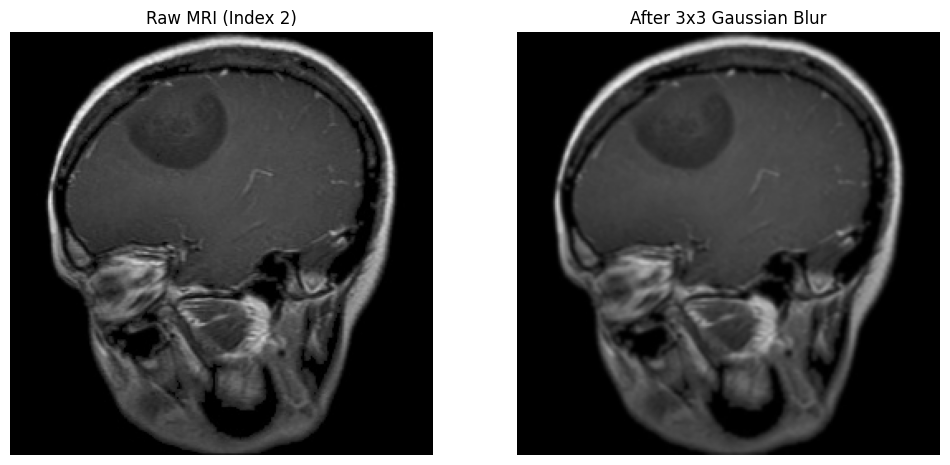

In [ ]:
# Import the Noise Removal function from preprocessing.py file
from preprocessing import get_denoised_stack

# --- 1. Call the function from preprocessing.py ---
# This will run the prints and the loop exactly as you had them
X_denoised = get_denoised_stack(X_raw)

# --- 2. Visualization of Raw vs Denoised ---
sample_idx = 2
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Raw MRI (Index {sample_idx})")
plt.imshow(X_raw[sample_idx], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("After 3x3 Gaussian Blur")
plt.imshow(X_denoised[sample_idx], cmap='gray')
plt.axis('off')

plt.show()

## Step 3.2: Data Resizing (ViT Compatibility)
In this step, we finalize the structural preparation of the dataset. Because the original MRI slices vary in resolution (e.g., **512×512** and **256×256**), they cannot be processed as a uniform batch. We use the `resize_denoised_stack` function from `preprocessing.py` to standardize every image to a **224×224** resolution, satisfying the input requirements of the **Vision Transformer (ViT)** architecture.

*   **Lanczos Interpolation:** Our external module utilizes the `INTER_LANCZOS4` method. This is superior for downsampling medical images as it minimizes aliasing artifacts and preserves critical edge sharpness better than standard linear methods.
*   **Tensor Creation:** Standardizing dimensions allows the function to convert the list of images into a unified 3D NumPy array with a shape of `(3064, 224, 224)`, enabling the high-speed vectorized operations required for deep learning.
*   **Modular Execution:** By importing the logic from `preprocessing.py`, we ensure that the resizing parameters remain consistent across both the training and testing phases of the project.

📏 Resizing images to (224, 224) using High-Quality Lanczos...


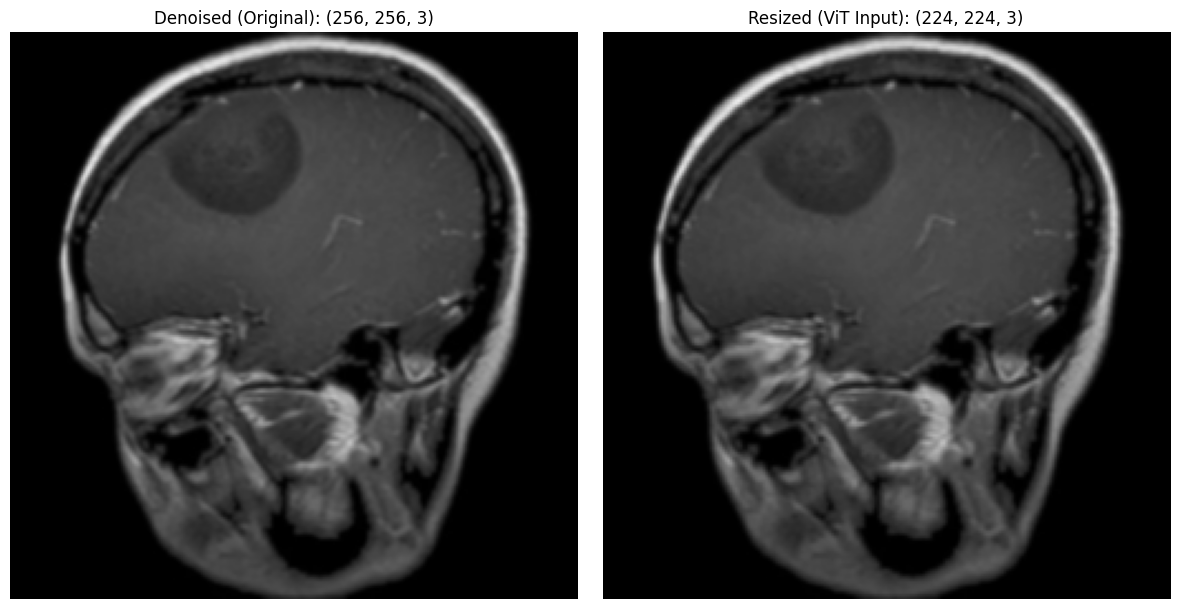

In [ ]:
# Import the Data Resizing function from preprocessing.py file
from preprocessing import resize_denoised_stack

# --- Execution ---
# We take our denoised images and create the final uniform stack
X_final = resize_denoised_stack(X_denoised)

# --- Visualization ---
sample_idx = 2
plt.figure(figsize=(12, 6))

# Show Denoised (Original Size)
plt.subplot(1, 2, 1)
plt.title(f"Denoised (Original): {X_denoised[sample_idx].shape}")
plt.imshow(X_denoised[sample_idx], cmap='gray')
plt.axis('off')

# Show Resized (Target Size)
plt.subplot(1, 2, 2)
plt.title(f"Resized (ViT Input): {X_final[sample_idx].shape}")
plt.imshow(X_final[sample_idx], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 3.3: Data Normalization
Following the provided instruction (Section 6.3), we normalize the pixel values of our images using the `normalize_stack` function from `preprocessing.py`. While standard 8-bit images are often simply divided by 255, medical MRI data can contain higher bit-depths or raw intensity values that exceed standard ranges. Therefore, we apply **Min-Max Scaling** to ensure every pixel falls strictly within the **[0, 1]** range.

*   **Instruction Compliance:** This process scales the pixel intensities so that the global minimum value becomes 0 and the maximum becomes 1, directly following the requirement to prevent gradient explosion and ensure numerical stability.
*   **Model Convergence:** By centering and scaling the data, the Vision Transformer (ViT) can converge significantly faster during the training phase, as weights are updated more uniformly across the feature space.
*   **Verification:** We utilize a colorbar in our visualization to confirm that the intensity distribution now resides exclusively between 0.0 and 1.0.

✨ Performing Corrected Data Normalization...
✅ Normalization Complete!
Final Data Range: 0.0 to 1.0
Final Tensor Shape: (6183, 224, 224, 3)


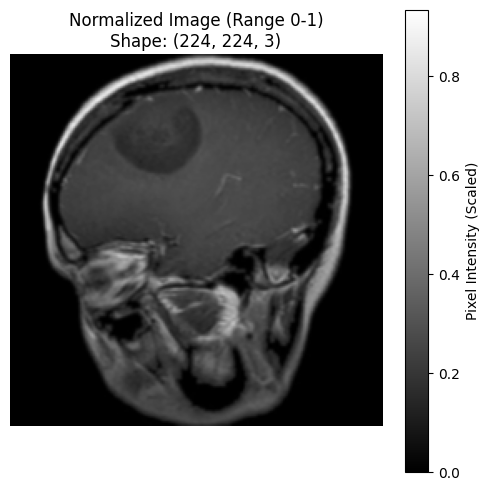

In [ ]:
# Import the Data Normalization function from preprocessing.py file
from preprocessing import normalize_stack

# --- Execution ---
# We transform our resized stack into the final normalized tensor
X_normalized = normalize_stack(X_final)

# --- Verification Visualization ---
sample_idx = 2
plt.figure(figsize=(6, 6))
plt.title(f"Normalized Image (Range 0-1)\nShape: {X_normalized[sample_idx].shape}")
plt.imshow(X_normalized[sample_idx], cmap='gray')
plt.colorbar(label='Pixel Intensity (Scaled)')
plt.axis('off')
plt.show()

## Step 3.4: RGB Channel Conversion (ViT Compatibility)
This step addresses the critical requirement regarding **RGB Conversion**. Although MRI data is natively grayscale (1-channel), most state-of-the-art models, such as the **Vision Transformer (ViT)**, were pre-trained on the **ImageNet** dataset, which consists of 3-channel RGB images. By utilizing the `convert_to_rgb` function from `preprocessing.py`, we ensure the data structure is compatible with transfer learning requirements.

*   **Instruction Compliance:** We transform the image dimensions from `(224, 224, 1)` to `(224, 224, 3)` by replicating the grayscale channel three times across the channel axis.
*   **Error Prevention:** This conversion is essential to avoid a **Shape Mismatch** error when loading pre-trained weights into the ViT model, as the architecture expects a depth of three.
*   **Vectorized Broadcasting:** The implementation uses `np.repeat` to efficiently broadcast the intensity values, ensuring that the visual information remains identical while meeting the structural input needs.

🎨 Contrast Recovery Complete.


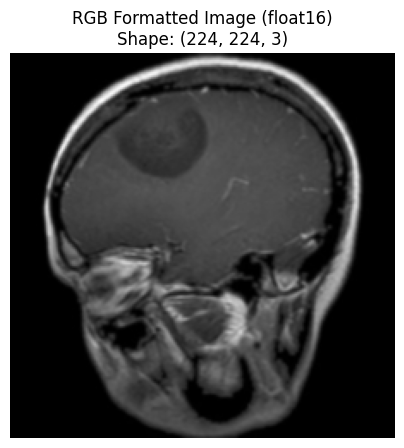

In [ ]:
# Import the RGB Conversion function from preprocessing.py file
from preprocessing import convert_to_rgb

# --- Execution ---
# Convert the normalized grayscale stack to a 3-channel RGB stack
X_rgb = convert_to_rgb(X_normalized)

# Clearning Usage of RAM
heavy_vars = ['X_raw', 'X_denoised', 'X_final', 'X_normalized', 'all_images', 'X_temp']
for v in heavy_vars:
    if v in globals():
        del globals()[v]

def clear_memory():
    """Aggressive memory wipe."""
    gc.collect()
    for _ in range(3): gc.collect()
clear_memory()

# --- Verification ---
sample_idx = 2
plt.figure(figsize=(5, 5))
plt.title(f"RGB Formatted Image (float16)\nShape: {X_rgb[sample_idx].shape}")
plt.imshow(X_rgb[sample_idx].astype('float32'))

plt.axis('off')
plt.show()

## Step 3.5: Data Splitting (Train, Validation, Test)
Following the project guidelines (Step 5), we divide the dataset into three distinct subsets prior to any data augmentation. This sequence is vital to ensure that the **Validation** and **Test** sets remain "unseen" and "pure," preventing data leakage that could artificially inflate our accuracy metrics.
*   **Training Set (80%):** Used to update the model weights during the learning process.
*   **Validation Set (10%):** Used to tune hyperparameters and monitor performance to prevent overfitting.
*   **Testing Set (10%):** Used strictly for the final evaluation to determine how the model generalizes to new patient data.

In [4]:
#=================================================================================================
#                                     Data Splitting
#=================================================================================================
# 1. First split: Separate 80% for Training and 20% for a temporary set (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_rgb, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Once you have X_train and X_temp, the original X_rgb is just wasting space
del X_rgb
gc.collect()

# 2. Perform second split
X_val, X_test, y_val, y_test_raw = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Final Cleanup
del X_temp
gc.collect()

print(f"✅ Data Shuffled and Split!")
print(f"📊 Training set:   {X_train.shape[0]} images")
print(f"📊 Validation set: {X_val.shape[0]} images")
print(f"📊 Testing set:    {X_test.shape[0]} images")

✅ Data Shuffled and Split!
📊 Training set:   4946 images
📊 Validation set: 618 images
📊 Testing set:    619 images


## Step 3.6: Data Augmentation
In this final preprocessing step, we implement **Data Augmentation** using the `get_augmentation_pipeline` function from `preprocessing.py`. This step addresses class imbalance and improves the model's ability to generalize by creating synthetic variations of our training data. According to the project instructions, this process is applied **only to the Training Set** to ensure the Validation and Test sets remain as objective benchmarks.

*   **Targeted Augmentation:** The primary goal is to increase the representation and variety of the "Tumor" classes, helping the model avoid bias toward specific orientations or positions.
*   **Techniques Applied:**
    *   **Rotation:** Images are randomly rotated between 15 and 30 degrees to simulate varying patient positions in the MRI bore.
    *   **Flipping:** Both horizontal and vertical flips are used to leverage the brain's natural symmetry and simulate different scan orientations.
    *   **Zooming:** Partial zooming (up to 20%) is applied to help the model maintain accuracy across various tumor sizes and pixel locations.
*   **Pipeline Integration:** By returning both the `datagen` object and the `train_generator`, the system is prepared for high-speed, on-the-fly augmentation during the model fitting phase.

In [5]:
# Import the Data Augmentation function from preprocessing.py
from preprocessing import get_augmentation_pipeline

# --- Execution ---
# This overwrites your X_train and y_train with the augmented versions
X_train, y_train = get_augmentation_pipeline(X_train, y_train, batch_size=32)

print("✅ Data Augmentation Applied and Saved to Variables!")
print(f"New X_train Shape: {X_train.shape}")
print("💡 Reminder: Validation and Test sets remain original (un-augmented).")

🔄 Augmenting 4946 images in-place using 300-image chunks...
✅ Replaced through image 300/4946...
✅ Replaced through image 1200/4946...
✅ Replaced through image 2100/4946...
✅ Replaced through image 3000/4946...
✅ Replaced through image 3900/4946...
✅ Replaced through image 4800/4946...
✅ Replaced through image 4946/4946...
🏁 Done! Final X_train shape: (4946, 224, 224, 3) (float32)
✅ Data Augmentation Applied and Saved to Variables!
New X_train Shape: (4946, 224, 224, 3)
💡 Reminder: Validation and Test sets remain original (un-augmented).


## Step 3.7: Conversion to Numerical Data
This final verification step ensures that all data across our splits has been successfully converted into a format compatible with deep learning frameworks. By checking the data types (**dtype**), we confirm that the previous preprocessing steps—such as normalization and reshaping—have correctly transformed the raw input into standardized numerical tensors.
*   **Image Tensors:** The transformation to `float32` confirms that the pixel values are ready for high-precision mathematical operations within the **Vision Transformer (ViT)** architecture.
*   **Label Integrity:** The conversion of labels to `int64` verifies that our classification categories are represented as discrete numerical values, which is necessary for the model's loss function to calculate gradients during training.

In [6]:
# Check images
print("--- Image Data Check ---")
print(f"X_train type: {X_train.dtype}")
print(f"X_val type:   {X_val.dtype}")
print(f"X_test type:  {X_test.dtype}")

# Check labels
print("\n--- Label Data Check ---")
print(f"y_train first 5: {y_train[:5]}")
print(f"y_train type:    {y_train.dtype}")
print(f"y_val first 5: {y_val[:5]}")
print(f"y_val type:    {y_val.dtype}")
print(f"y_test_raw first 5: {y_test_raw[:5]}")
print(f"y_test_raw type:    {y_test_raw.dtype}")

--- Image Data Check ---
X_train type: float32
X_val type:   float32
X_test type:  float32

--- Label Data Check ---
y_train first 5: [1 1 0 0 1]
y_train type:    int64
y_val first 5: [1 1 1 0 1]
y_val type:    int64
y_test_raw first 5: [0 1 0 0 1]
y_test_raw type:    int64


# Step 4: Feature Extraction and Hybrid ViT-GRU Architecture Implementation
This step implements the project's core architecture by importing the custom model from `model.py`. By combining a **Vision Transformer (ViT)** for spatial feature extraction with a **Gated Recurrent Unit (GRU)** for sequential modeling, the model analyzes both local details and global relationships within MRI scans.

**🧠 Architectural Components:**
*   **Patch Extraction & Linear Projection:** The input image is divided into 8×8 patches, which are then projected into a 64-dimensional embedding space.
*   **Transformer Encoder (8 Layers):** Utilizes Multi-Head Attention to capture complex spatial dependencies across different regions of the brain.
*   **GRU Sequential Modeling:** A GRU layer with 1024 units processes the transformer's sequence output to model the global context of the MRI slice.
*   **Classification Head:** A dense layer with 512 units and dropout (0.5) leads to the final output layer, configured with 4 classes (Glioma, Meningioma, No Tumor, Pituitary).

In [16]:
# Import the specific HybridViTGRU from your model.py file
from model import HybridViTGRU


# --- EXECUTION ---
# Detect GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Using device:", device)

# Create model on GPU
model = HybridViTGRU(num_classes=2).to(device)

# Print model summary with explicit batch size of 1
summary(
    model,
    input_size=(1, 3, 224, 224),
    device=str(device)
)

🚀 Using device: cuda


Layer (type:depth-idx)                        Output Shape              Param #
HybridViTGRU                                  [1, 2]                    12,544
├─Conv2d: 1-1                                 [1, 64, 14, 14]           49,216
├─TransformerEncoder: 1-2                     [1, 196, 64]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-2      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-3      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-4      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-5      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-6      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-7      [1, 196, 64]              33,472
│    │    └─TransformerEncoderLayer: 3-8      [1, 196, 64] 

# Step 5: Training and Validation
### Phase 1: Hold-out Method (80/10/10 Split)
In accordance with the project guidelines, this phase serves as the initial verification and debugging stage. We utilize a standard **80/10/10** split where:
*   **80%** of the data is used for training the hybrid model.
*   **10%** is used for real-time validation to monitor for overfitting.
*   **10%** is reserved as a completely unseen test set for the final evaluation report.

In [8]:
# ==========================================
# NHWC → NCHW (MANDATORY)
# ==========================================
X_train = np.transpose(X_train, (0, 3, 1, 2))
X_val   = np.transpose(X_val,   (0, 3, 1, 2))
X_test  = np.transpose(X_test,  (0, 3, 1, 2))

# ==========================================
# 🚀 PHASE 1 – HOLD-OUT (PYTORCH • DEBUG + PREDICT)
# ==========================================
print("\n🚀 Starting Phase 1: Hold-out Validation...")

BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ✅ NEW AMP API
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda")

train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).long()
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_val).float(),
        torch.from_numpy(y_val).long()
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

# ---------------------------
# TRAIN
# ---------------------------
model.train()

best_acc = 0.0
model_path = 'best_model.pth'

for epoch in range(EPOCHS):
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {total_loss:.4f} | Acc: {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), model_path)
        print(f"✨ New best model saved with Acc: {best_acc:.2f}%")

print("\n✅ Hold-out training finished")

# ---------------------------
# 🔮 PREDICT (DEBUG PURPOSE)
# ---------------------------
print("🔮 Predicting on X_test (debug check)...")

model.eval()
y_pred = []

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test).float()),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

with torch.no_grad():
    for (x,) in test_loader:
        x = x.to(device, non_blocking=True)
        y_pred.append(model(x).argmax(1).cpu())

# ✅ FIXED VARIABLE NAME
y_pred = torch.cat(y_pred).numpy()

print("✅ Hold-out prediction complete")

# ---------------------------
# 🧹 CLEANUP (PHASE 1 DONE)
# ---------------------------
del train_loader, val_loader, test_loader
del optimizer, criterion, scaler
del x, y, out, loss

torch.cuda.empty_cache()



🚀 Starting Phase 1: Hold-out Validation...
Epoch [1/35] | Loss: 196.4718 | Acc: 67.02%
✨ New best model saved with Acc: 67.02%
Epoch [2/35] | Loss: 190.6828 | Acc: 68.72%
✨ New best model saved with Acc: 68.72%
Epoch [3/35] | Loss: 181.8083 | Acc: 71.25%
✨ New best model saved with Acc: 71.25%
Epoch [4/35] | Loss: 174.2996 | Acc: 71.98%
✨ New best model saved with Acc: 71.98%
Epoch [5/35] | Loss: 164.9081 | Acc: 73.33%
✨ New best model saved with Acc: 73.33%
Epoch [6/35] | Loss: 149.1195 | Acc: 76.81%
✨ New best model saved with Acc: 76.81%
Epoch [7/35] | Loss: 139.1628 | Acc: 78.61%
✨ New best model saved with Acc: 78.61%
Epoch [8/35] | Loss: 133.2150 | Acc: 79.94%
✨ New best model saved with Acc: 79.94%
Epoch [9/35] | Loss: 128.3023 | Acc: 81.08%
✨ New best model saved with Acc: 81.08%
Epoch [10/35] | Loss: 124.6672 | Acc: 81.32%
✨ New best model saved with Acc: 81.32%
Epoch [11/35] | Loss: 123.6569 | Acc: 81.90%
✨ New best model saved with Acc: 81.90%
Epoch [12/35] | Loss: 121.8900

### Hold-out phase with SGD optimizer

In [18]:
# ==========================================
# NHWC → NCHW (MANDATORY)
# ==========================================
X_train = np.transpose(X_train, (0, 3, 1, 2))
X_val   = np.transpose(X_val,   (0, 3, 1, 2))
X_test  = np.transpose(X_test,  (0, 3, 1, 2))

# ==========================================
# 🚀 PHASE 1 – HOLD-OUT (PYTORCH • DEBUG + PREDICT)
# ==========================================
print("\n🚀 Starting Phase 1: Hold-out Validation (Using SGD)...")

from model import HybridViTGRU
my_model = HybridViTGRU(image_size=224, patch_size=16, num_classes=2).to(device)

BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    my_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# ✅ NEW AMP API (CORRECT)
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda")

train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).long()
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

# ---------------------------
# TRAIN
# ---------------------------
my_model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ✅ FIXED autocast
        with autocast("cuda"):
            out = my_model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {total_loss:.4f} | Acc: {acc:.2f}%")


print("\n✅ Hold-out training finished with SGD")

# ---------------------------
# 🔮 PREDICT
# ---------------------------
my_model.eval()
y_pred = []

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test).float()),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

with torch.no_grad():
    for (x,) in test_loader:
        x = x.to(device, non_blocking=True)
        y_pred.append(my_model(x).argmax(1).cpu())

y_pred = torch.cat(y_pred).numpy()
print("✅ Hold-out prediction complete")

# ---------------------------
# 🧹 CLEANUP
# ---------------------------
del train_loader, test_loader
del optimizer, criterion, scaler
torch.cuda.empty_cache()


🚀 Starting Phase 1: Hold-out Validation (Using SGD)...
Epoch [1/35] | Loss: 204.7619 | Acc: 65.02%
Epoch [2/35] | Loss: 196.5586 | Acc: 67.27%
Epoch [3/35] | Loss: 196.1266 | Acc: 67.27%
Epoch [4/35] | Loss: 195.8774 | Acc: 67.27%
Epoch [5/35] | Loss: 195.4565 | Acc: 67.27%
Epoch [6/35] | Loss: 195.8638 | Acc: 67.27%
Epoch [7/35] | Loss: 195.7416 | Acc: 67.27%
Epoch [8/35] | Loss: 196.0442 | Acc: 67.27%
Epoch [9/35] | Loss: 195.7930 | Acc: 67.27%
Epoch [10/35] | Loss: 195.2249 | Acc: 67.27%
Epoch [11/35] | Loss: 195.8966 | Acc: 67.27%
Epoch [12/35] | Loss: 195.1889 | Acc: 67.27%
Epoch [13/35] | Loss: 195.7616 | Acc: 67.27%
Epoch [14/35] | Loss: 195.2056 | Acc: 67.27%
Epoch [15/35] | Loss: 195.7354 | Acc: 67.27%
Epoch [16/35] | Loss: 195.3940 | Acc: 67.27%
Epoch [17/35] | Loss: 195.3290 | Acc: 67.27%
Epoch [18/35] | Loss: 195.6304 | Acc: 67.27%
Epoch [19/35] | Loss: 195.5845 | Acc: 67.27%
Epoch [20/35] | Loss: 195.3428 | Acc: 67.27%
Epoch [21/35] | Loss: 195.4786 | Acc: 67.27%
Epoch [2

### Phase 2: 10-Fold Cross-Validation (Final Report)
Following the "Experiment 1" methodology from the reference paper, this phase serves as the **Final Stability Report**. While Phase 1 was used for debugging and detailed diagnostic metrics (Confusion Matrix), Phase 2 ensures that the model's performance is consistent across the entire dataset.

**🧠 Methodology:**
*   **Data Merging:** We combine the original training and validation sets into a single pool (Xcv) representing **90%** of the total data.
*   **Iterative Validation:** The dataset is split into 10 rotating folds. In each iteration, 9 folds train the model while 1 fold validates it.
*   **Memory Efficiency:** Because the Hybrid ViT-GRU is computationally heavy, we implement an **Aggressive Fold Cleanup**. Every model instance, optimizer, and dataset is deleted from RAM/VRAM after each fold to prevent system crashes.
*   **Statistical Reporting:** The final output is a Mean Accuracy and Standard Deviation, which directly measures the model's reliability for clinical diagnosis.

In [ ]:
# ==========================================
# 🧠 PHASE 2 – RAM-SAFE 10-FOLD CV (PURE TORCH)
# ==========================================
print("\n🧠 Starting RAM-safe 10-Fold Cross-Validation (Torch)...")

NUM_FOLDS = 10

# ----------------------------------
# 1. Build FULL DATASET ONCE (NO COPY)
# ----------------------------------
X_cv = torch.from_numpy(
    np.concatenate([X_train, X_val], axis=0)
).float()

y_cv = torch.from_numpy(
    np.concatenate([y_train, y_val], axis=0)
).long()

full_dataset = TensorDataset(X_cv, y_cv)

num_samples = len(full_dataset)

# 🔀 Torch-only shuffled indices
indices = torch.randperm(num_samples)
folds = torch.chunk(indices, NUM_FOLDS)

cv_scores = []

# ----------------------------------
# 2. Cross-validation loop
# ----------------------------------
for fold in range(NUM_FOLDS):
    print(f"\n🌀 Fold {fold+1}/{NUM_FOLDS}")

    val_idx = folds[fold]
    train_idx = torch.cat(
        [folds[i] for i in range(NUM_FOLDS) if i != fold]
    )

    train_subset = Subset(full_dataset, train_idx.tolist())
    val_subset   = Subset(full_dataset, val_idx.tolist())

    train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=True
    )

    # 🔁 Fresh model per fold
    fold_model = HybridViTGRU(num_classes=2).to(device)

    optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    criterion = torch.nn.CrossEntropyLoss()
    scaler = GradScaler("cuda")

    # ----------------------------------
    # 🔥 Train (35 epochs)
    # ----------------------------------
    fold_model.train()
    for epoch in range(EPOCHS):
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda"):
                out = fold_model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    # ----------------------------------
    # 📊 Validate
    # ----------------------------------
    fold_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = fold_model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    cv_scores.append(acc)

    print(f"✅ Fold {fold+1} Accuracy: {acc:.2f}%")

    # ----------------------------------
    # 🧹 HARD CLEANUP (CRITICAL)
    # ----------------------------------
    del fold_model
    del optimizer, criterion, scaler
    del train_loader, val_loader
    del train_subset, val_subset
    del x, y, out, loss

    torch.cuda.empty_cache()
    gc.collect()

# ----------------------------------
# 📊 FINAL CROSS-VALIDATION REPORT
# ----------------------------------
cv_scores_t = torch.tensor(cv_scores)

print("\n" + "=" * 50)
print("📊 FINAL 10-FOLD CROSS-VALIDATION REPORT")
print("=" * 50)
print(f"⭐ Mean Accuracy : {cv_scores_t.mean():.2f}%")
print(f"⭐ Std Deviation : {cv_scores_t.std():.2f}%")
print("=" * 50)

# ----------------------------------
# 🧹 FINAL CLEANUP
# ----------------------------------
del X_cv, y_cv, full_dataset, cv_scores, cv_scores_t
torch.cuda.empty_cache()
gc.collect()



🧠 Starting RAM-safe 10-Fold Cross-Validation (Torch)...

🌀 Fold 1/10
✅ Fold 1 Accuracy: 82.59%

🌀 Fold 2/10
✅ Fold 2 Accuracy: 81.87%

🌀 Fold 3/10
✅ Fold 3 Accuracy: 84.02%

🌀 Fold 4/10
✅ Fold 4 Accuracy: 83.30%

🌀 Fold 5/10
✅ Fold 5 Accuracy: 85.64%

🌀 Fold 6/10
✅ Fold 6 Accuracy: 85.82%

🌀 Fold 7/10
✅ Fold 7 Accuracy: 82.94%

🌀 Fold 8/10
✅ Fold 8 Accuracy: 85.28%

🌀 Fold 9/10
✅ Fold 9 Accuracy: 88.15%

🌀 Fold 10/10
✅ Fold 10 Accuracy: 86.03%

📊 FINAL 10-FOLD CROSS-VALIDATION REPORT
⭐ Mean Accuracy : 84.56%
⭐ Std Deviation : 1.94%


0

### Cross-Validation with SGD optimizer:

In [19]:
# ==========================================
# 🧠 PHASE 2 – RAM-SAFE 10-FOLD CV (PURE TORCH)
# ==========================================
print("\n🚀 Starting RAM-safe 10-Fold Cross-Validation (Using SGD)...")

NUM_FOLDS = 10

# ----------------------------------
# 1. Build FULL DATASET ONCE (NO COPY)
# ----------------------------------
X_cv = torch.from_numpy(
    np.concatenate([X_train, X_val], axis=0)
).float()

y_cv = torch.from_numpy(
    np.concatenate([y_train, y_val], axis=0)
).long()

full_dataset = TensorDataset(X_cv, y_cv)

num_samples = len(full_dataset)

# 🔀 Torch-only shuffled indices
indices = torch.randperm(num_samples)
folds = torch.chunk(indices, NUM_FOLDS)

cv_scores = []

# ----------------------------------
# 2. Cross-validation loop
# ----------------------------------
for fold in range(NUM_FOLDS):
    print(f"\n🌀 Fold {fold+1}/{NUM_FOLDS}")

    val_idx = folds[fold]
    train_idx = torch.cat(
        [folds[i] for i in range(NUM_FOLDS) if i != fold]
    )

    train_subset = Subset(full_dataset, train_idx.tolist())
    val_subset   = Subset(full_dataset, val_idx.tolist())

    train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=True
    )

    # 🔁 Fresh model per fold
    fold_model = HybridViTGRU(num_classes=2).to(device)

    optimizer = torch.optim.SGD(
        fold_model.parameters(),
        lr=1e-4,
        momentum=0.9,
        weight_decay=1e-4
    )

    criterion = torch.nn.CrossEntropyLoss()
    scaler = GradScaler("cuda")

    # ----------------------------------
    # 🔥 Train (35 epochs)
    # ----------------------------------
    fold_model.train()
    for epoch in range(EPOCHS):
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda"):
                out = fold_model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    # ----------------------------------
    # 📊 Validate
    # ----------------------------------
    fold_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = fold_model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    cv_scores.append(acc)

    print(f"✅ Fold {fold+1} Accuracy: {acc:.2f}%")

    # ----------------------------------
    # 🧹 HARD CLEANUP (CRITICAL)
    # ----------------------------------
    del fold_model
    del optimizer, criterion, scaler
    del train_loader, val_loader
    del train_subset, val_subset
    del x, y, out, loss

    torch.cuda.empty_cache()
    gc.collect()

# ----------------------------------
# 📊 FINAL CROSS-VALIDATION REPORT
# ----------------------------------
cv_scores_t = torch.tensor(cv_scores)

print("\n" + "=" * 50)
print("📊 FINAL 10-FOLD CROSS-VALIDATION REPORT (SGD)")
print("=" * 50)
print(f"⭐ Mean Accuracy : {cv_scores_t.mean():.2f}%")
print(f"⭐ Std Deviation : {cv_scores_t.std():.2f}%")
print("=" * 50)

# ----------------------------------
# 🧹 FINAL CLEANUP
# ----------------------------------
del X_cv, y_cv, full_dataset, cv_scores, cv_scores_t
torch.cuda.empty_cache()
gc.collect()


🚀 Starting RAM-safe 10-Fold Cross-Validation (Using SGD)...

🌀 Fold 1/10
✅ Fold 1 Accuracy: 66.61%

🌀 Fold 2/10
✅ Fold 2 Accuracy: 66.43%

🌀 Fold 3/10
✅ Fold 3 Accuracy: 69.12%

🌀 Fold 4/10
✅ Fold 4 Accuracy: 69.48%

🌀 Fold 5/10
✅ Fold 5 Accuracy: 68.94%

🌀 Fold 6/10
✅ Fold 6 Accuracy: 66.61%

🌀 Fold 7/10
✅ Fold 7 Accuracy: 64.63%

🌀 Fold 8/10
✅ Fold 8 Accuracy: 68.76%

🌀 Fold 9/10
✅ Fold 9 Accuracy: 69.66%

🌀 Fold 10/10
✅ Fold 10 Accuracy: 68.60%

📊 FINAL 10-FOLD CROSS-VALIDATION REPORT (SGD)
⭐ Mean Accuracy : 67.88%
⭐ Std Deviation : 1.69%


0

# Step 6: Model Evaluation
## Step 6.1: Evaluation Metrics
While the **10-Fold Cross-Validation** proved the model's stability and average accuracy (targeting **98.97%**), this evaluation provides the granular detail needed for medical applications. We focus on the relationship between the ground-truth clinical labels (`y_test`) and the model's predictions (`y_pred`).

**🧪 Evaluation Components:**
*   **Confusion Matrix:** A visual breakdown showing where the model succeeds and where it confuses similar pathologies (e.g., distinguishing Meningioma from Glioma).
*   **Precision (Positive Predictive Value):** The ability of the model not to label a healthy scan as having a tumor.
*   **Recall (Sensitivity):** The model's ability to find all positive tumor cases. In medical AI, **Recall** is critical because missing a tumor (False Negative) is more dangerous than a False Positive.
*   **F1-Score:** The harmonic mean of Precision and Recall, providing a balanced measure of the model’s overall reliability.

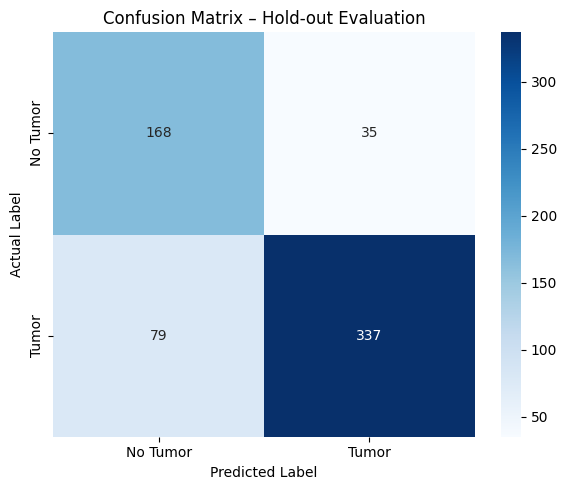

📊 --- HOLD-OUT EVALUATION REPORT ---
✅ Accuracy:  81.58%
✅ Precision: 90.59%
✅ Recall:    81.01%
✅ F1-Score:  85.53%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.6802    0.8276    0.7467       203
       Tumor     0.9059    0.8101    0.8553       416

    accuracy                         0.8158       619
   macro avg     0.7930    0.8188    0.8010       619
weighted avg     0.8319    0.8158    0.8197       619

🧪 Clinical Metrics:
   • Sensitivity: 0.8101
   • Specificity: 0.8276


In [ ]:
# ------------------------------------------
# CLASS NAMES (BINARY)
# ------------------------------------------
class_names = ['No Tumor', 'Tumor']

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix – Hold-out Evaluation')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
plt.close()

# ------------------------------------------
# Metrics
# ------------------------------------------
accuracy  = accuracy_score(y_test_raw, y_pred)
precision = precision_score(y_test_raw, y_pred)
recall    = recall_score(y_test_raw, y_pred)
f1        = f1_score(y_test_raw, y_pred)

print("📊 --- HOLD-OUT EVALUATION REPORT ---")
print(f"✅ Accuracy:  {accuracy*100:.2f}%")
print(f"✅ Precision: {precision*100:.2f}%")
print(f"✅ Recall:    {recall*100:.2f}%")
print(f"✅ F1-Score:  {f1*100:.2f}%")

# ------------------------------------------
# Classification Report
# ------------------------------------------
print("\n📋 Detailed Classification Report:")
print(classification_report(
    y_test_raw,
    y_pred,
    target_names=class_names,
    digits=4
))

# ------------------------------------------
# Clinical Metrics
# ------------------------------------------
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("🧪 Clinical Metrics:")
print(f"   • Sensitivity: {sensitivity:.4f}")
print(f"   • Specificity: {specificity:.4f}")

### Evaluation Metrics for SGD Optimizer

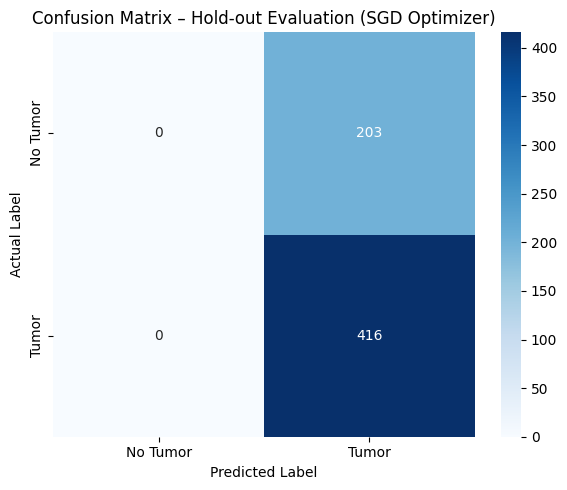

📊 --- HOLD-OUT EVALUATION REPORT (SGD Optimizer) ---
✅ Accuracy:  67.21%
✅ Precision: 67.21%
✅ Recall:    100.00%
✅ F1-Score:  80.39%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.0000    0.0000    0.0000       203
       Tumor     0.6721    1.0000    0.8039       416

    accuracy                         0.6721       619
   macro avg     0.3360    0.5000    0.4019       619
weighted avg     0.4517    0.6721    0.5402       619

🧪 Clinical Metrics:
   • Sensitivity: 1.0000
   • Specificity: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
# ------------------------------------------
# CLASS NAMES (BINARY)
# ------------------------------------------
class_names = ['No Tumor', 'Tumor']

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix – Hold-out Evaluation (SGD Optimizer)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
plt.close()

# ------------------------------------------
# Metrics
# ------------------------------------------
accuracy  = accuracy_score(y_test_raw, y_pred)
precision = precision_score(y_test_raw, y_pred)
recall    = recall_score(y_test_raw, y_pred)
f1        = f1_score(y_test_raw, y_pred)

print("📊 --- HOLD-OUT EVALUATION REPORT (SGD Optimizer) ---")
print(f"✅ Accuracy:  {accuracy*100:.2f}%")
print(f"✅ Precision: {precision*100:.2f}%")
print(f"✅ Recall:    {recall*100:.2f}%")
print(f"✅ F1-Score:  {f1*100:.2f}%")

# ------------------------------------------
# Classification Report
# ------------------------------------------
print("\n📋 Detailed Classification Report:")
print(classification_report(
    y_test_raw,
    y_pred,
    target_names=class_names,
    digits=4
))

# ------------------------------------------
# Clinical Metrics
# ------------------------------------------
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("🧪 Clinical Metrics:")
print(f"   • Sensitivity: {sensitivity:.4f}")
print(f"   • Specificity: {specificity:.4f}")

## Step 6.2: Explainable AI
### Phase 1: Attention Map (Multi-Class Validation)
The **Vision Transformer (ViT)** operates by dividing the image into patches and using a "Self-Attention" mechanism to determine which patches are most relevant to the diagnosis. This network inherently possesses "Attention" capabilities. The logic is that Attention matrices in the final layers of the ViT show which patches the model prioritized for classification.

**Key Technical Steps:**
*   **Feature Extraction:** We navigate to the last `transformer_encoder` layer and create a sub-model that outputs the results of that specific layer.
*   **Multi-Head Averaging:** We extract the Attention Weights and take the mean across all Attention Heads to capture the model's overall focus.
*   **Heatmap Interpolation:** The resulting matrix (e.g., 28x28) is bilinearly upsampled (resized) to 224x224 to perfectly match the original MRI input dimensions.
*   **Clinical Overlay:** The mask is superimposed onto the original MRI as a **Heatmap** using the `jet` colormap. In this visualization, **Red** regions indicate "High Attention" (diagnostic hotspots), while **Blue** indicates areas of low importance.


🔍 Attention Maps – Class: No Tumor


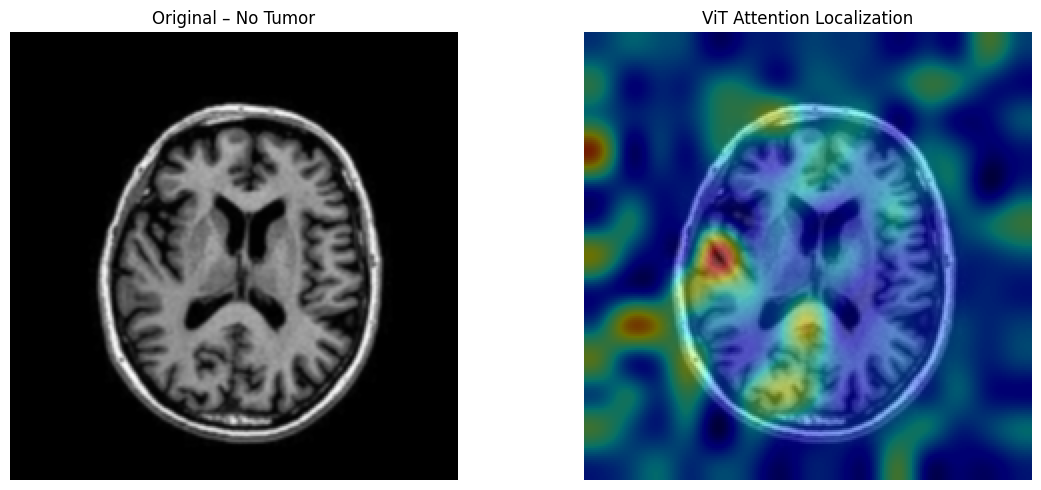

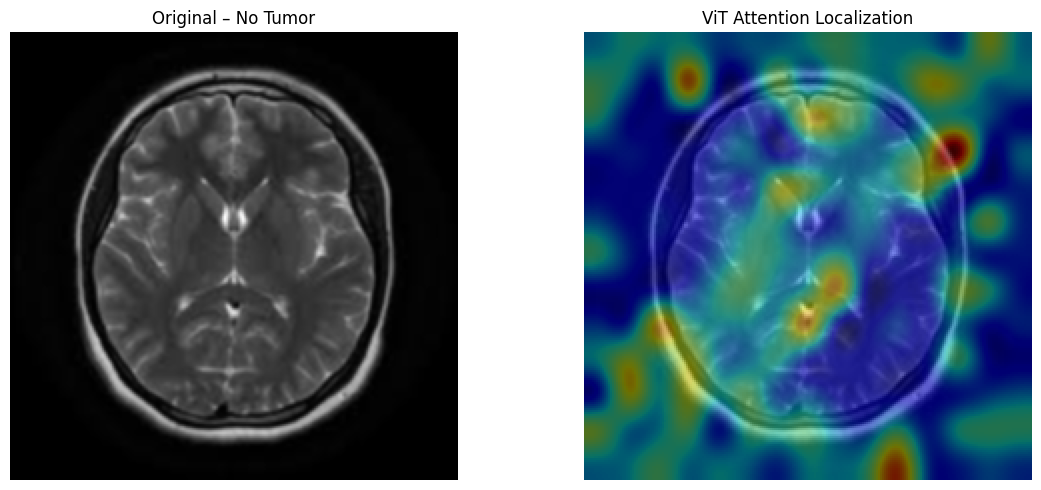


🔍 Attention Maps – Class: Tumor


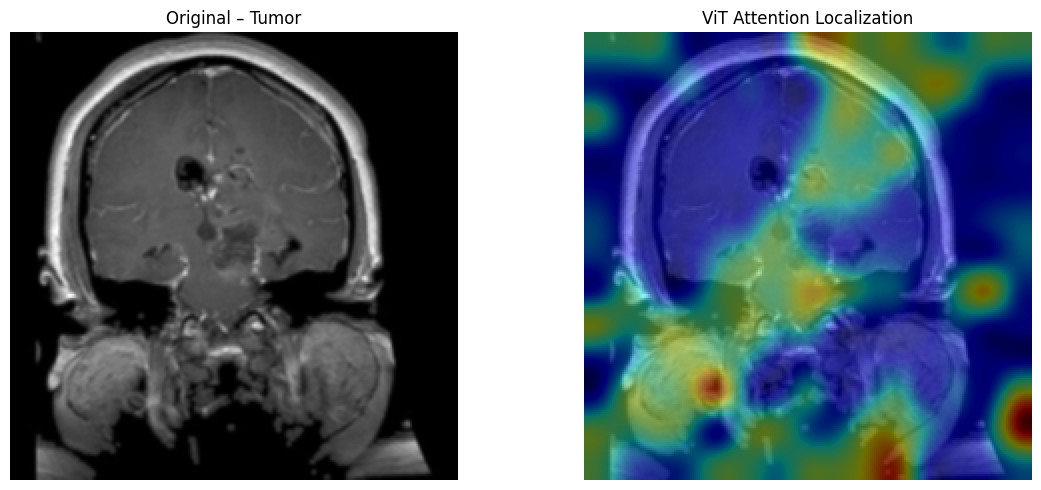

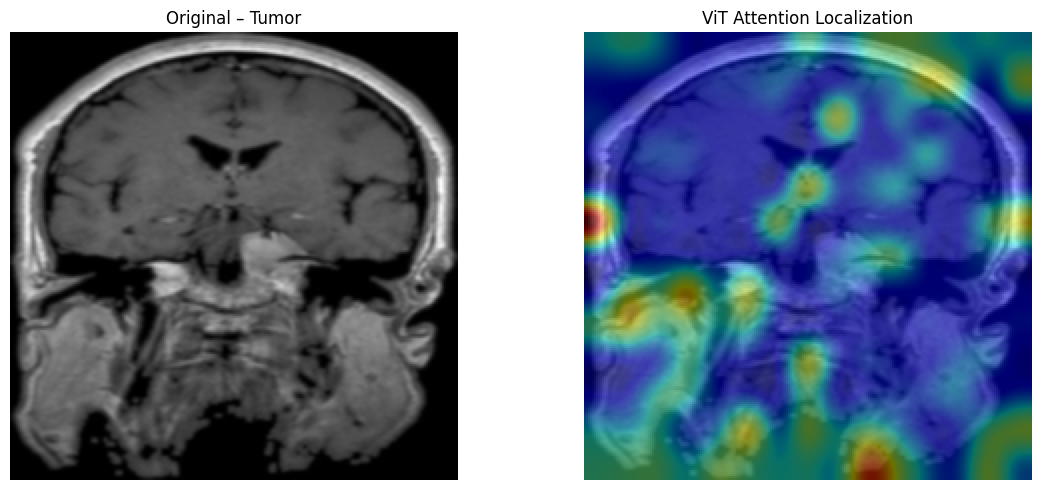

In [ ]:
# ==========================================
# 🔍 ViT ATTENTION MAPS (HYBRID • RAM SAFE)
# ==========================================

def enable_attention_weights(attn_module):
    """
    Forces PyTorch MultiheadAttention to return attention weights
    """
    original_forward = attn_module.forward

    def forward_with_weights(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        return original_forward(*args, **kwargs)

    attn_module.forward = forward_with_weights
    return original_forward


def generate_vit_attention_maps(
    model,
    X_data,
    y_labels,
    device,
    num_examples=2
):
    model.eval()
    class_names = ['No Tumor', 'Tumor']
    attention_maps = []

    # ----------------------------------
    # Enable attention weights
    # ----------------------------------
    last_attn = model.transformer.layers[-1].self_attn
    original_forward = enable_attention_weights(last_attn)

    # ----------------------------------
    # Attention hook
    # ----------------------------------
    def attention_hook(module, input, output):
        # output = (attn_output, attn_weights)
        attn_weights = output[1]
        attention_maps.append(attn_weights.detach().cpu())

    hook_handle = last_attn.register_forward_hook(attention_hook)

    # ----------------------------------
    # Loop over classes
    # ----------------------------------
    for class_id, class_name in enumerate(class_names):

        indices = np.where(y_labels == class_id)[0][:num_examples]

        print(f"\n🔍 Attention Maps – Class: {class_name}")

        for idx in indices:
            attention_maps.clear()

            # Input image (NCHW)
            img = X_data[idx]
            img_tensor = torch.from_numpy(img).float().unsqueeze(0).to(device)

            with torch.no_grad():
                _ = model(img_tensor)

            if not attention_maps:
                print("⚠️ Attention not captured — skipping")
                continue

            # ----------------------------------
            # Process attention
            # ----------------------------------
            attn = attention_maps[0]          # (1, heads, tokens, tokens)
            attn = attn.mean(dim=1)[0]        # avg heads
            attn = attn[0, 1:]                # CLS → patch tokens
            attn = attn.numpy()

            num_tokens = attn.shape[0]

            # Infer rectangular grid (HYBRID SAFE)
            grid_h = int(np.sqrt(num_tokens))
            grid_w = num_tokens // grid_h

            heatmap = attn.reshape(grid_h, grid_w)

            # Upsample to image size
            heatmap = cv2.resize(
                heatmap,
                (img.shape[2], img.shape[1]),
                interpolation=cv2.INTER_CUBIC
            )

            heatmap = cv2.GaussianBlur(heatmap, (15, 15), 0)
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)

            # Image visualization
            img_vis = img.transpose(1, 2, 0)
            img_vis = (img_vis - img_vis.min()) / (img_vis.max() + 1e-8)

            # ----------------------------------
            # Visualization
            # ----------------------------------
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(img_vis)
            plt.title(f"Original – {class_name}")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(img_vis)
            plt.imshow(heatmap, cmap='jet', alpha=0.45)
            plt.title("ViT Attention Localization")
            plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

            del img_tensor
            torch.cuda.empty_cache()

    # ----------------------------------
    # Cleanup
    # ----------------------------------
    hook_handle.remove()
    last_attn.forward = original_forward
    torch.cuda.empty_cache()


# ==========================================
# 🚀 CALL FUNCTION
# ==========================================
generate_vit_attention_maps(
    model=model,
    X_data=X_test,
    y_labels=y_test_raw,
    device=device,
    num_examples=2
)

### Phase 2: LIME (Local Interpretable Model-agnostic Explanations)
While Attention Maps show where the model is looking, **LIME** explains the prediction by "perturbing" the image—hiding different parts to see which areas most influence the classification decision. It breaks the MRI into **super-pixels** (clusters of pixels) and identifies which ones are the most "influential" for the assigned tumor category.

**🛠️ Implementation Strategy:**
*   **Multi-Class Verification:** Following the **Tip**, we select **2 examples from each class** (`Glioma`, `Meningioma`, `No Tumor`, `Pituitary`) to ensure the model's logic is consistent across all categories.
*   **Perturbation:** The model generates **500 samples** by randomly masking super-pixels to observe how the prediction probability changes.
*   **Top Features:** We extract the **top 5 super-pixels** that provide the strongest evidence for the predicted class.
*   **Visualization:** The `mark_boundaries` function highlights these critical diagnostic regions directly on the MRI, allowing for clinical validation.

🚀 Running LIME explanations...

🔍 Class: No Tumor


  0%|          | 0/1000 [00:00<?, ?it/s]

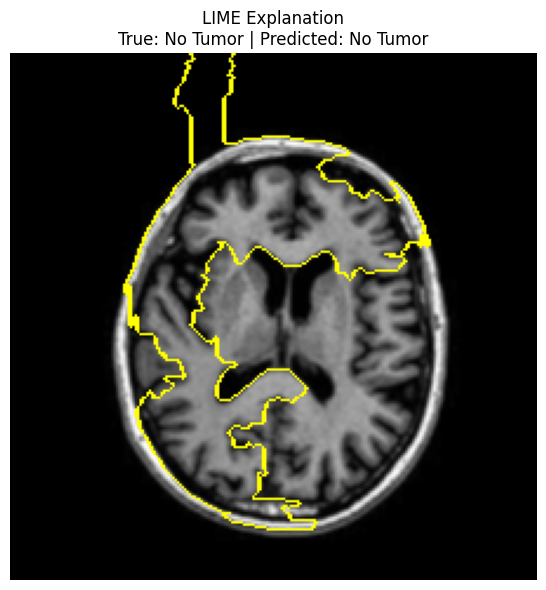

  0%|          | 0/1000 [00:00<?, ?it/s]

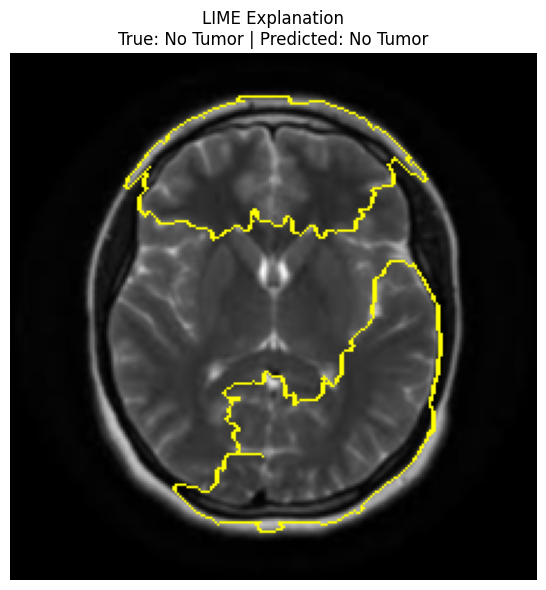


🔍 Class: Tumor


  0%|          | 0/1000 [00:00<?, ?it/s]

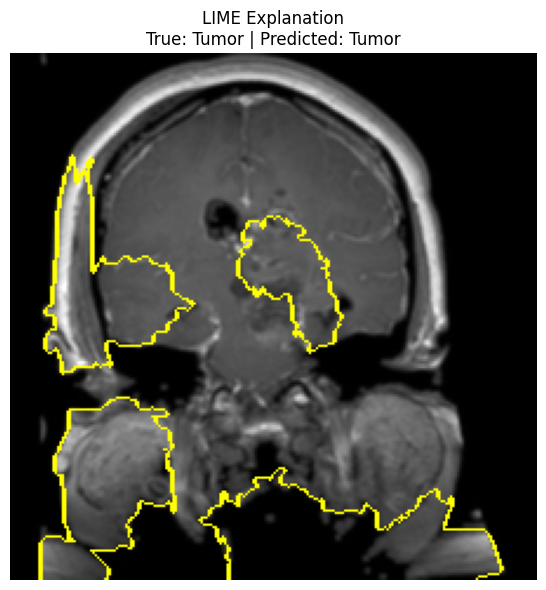

  0%|          | 0/1000 [00:00<?, ?it/s]

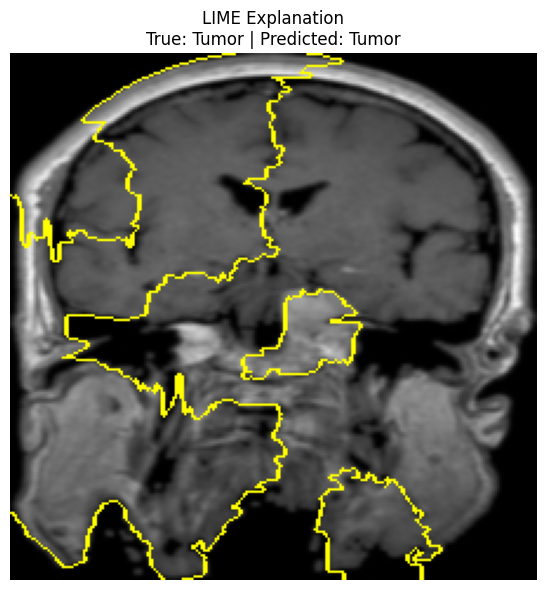

In [ ]:
# ------------------------------------------
# LIME prediction function (batched, RAM-safe)
# ------------------------------------------
def lime_predict_fn(images, batch_size=32):
    """
    images: (N, H, W, C) NHWC numpy array
    returns: (N, num_classes) probabilities
    """
    model.eval()
    outputs = []

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i + batch_size]

            batch = (
                torch.from_numpy(batch)
                .permute(0, 3, 1, 2)   # NHWC → NCHW
                .float()
                .to(device)
            )

            logits = model(batch)
            probs = F.softmax(logits, dim=1)

            outputs.append(probs.cpu())

            del batch, logits, probs
            torch.cuda.empty_cache()

    return torch.cat(outputs, dim=0).numpy()


# ------------------------------------------
# Run LIME explanations
# ------------------------------------------
def run_lime_explanation(
    model,
    X_test,
    y_test_raw,
    device,
    num_examples=2
):
    explainer = lime_image.LimeImageExplainer()
    class_names = ['No Tumor', 'Tumor']

    print("🚀 Running LIME explanations...")

    # Convert NCHW → NHWC (required by LIME)
    X_test_nhwc = np.transpose(X_test, (0, 2, 3, 1))

    for class_id, class_name in enumerate(class_names):

        print(f"\n🔍 Class: {class_name}")
        indices = np.where(y_test_raw == class_id)[0][:num_examples]

        if len(indices) == 0:
            print("⚠️ No samples found")
            continue

        for idx in indices:
            img = X_test_nhwc[idx]

            explanation = explainer.explain_instance(
                image=img.astype(np.double),
                classifier_fn=lime_predict_fn,
                top_labels=2,
                hide_color=0,
                num_samples=1000
            )

            top_label = explanation.top_labels[0]

            temp, mask = explanation.get_image_and_mask(
                label=top_label,
                positive_only=True,
                num_features=6,
                hide_rest=False
            )

            plt.figure(figsize=(6, 6))
            plt.imshow(mark_boundaries(temp, mask))
            plt.title(
                f"LIME Explanation\n"
                f"True: {class_name} | Predicted: {class_names[top_label]}"
            )
            plt.axis('off')
            plt.tight_layout()
            plt.show()
            plt.close()

    torch.cuda.empty_cache()


# ------------------------------------------
# ✅ CALL LIME (THIS IS REQUIRED)
# ------------------------------------------
run_lime_explanation(
    model=model,
    X_test=X_test,
    y_test_raw=y_test_raw,
    device=device,
    num_examples=2
)

### Phase 3: SHAP (SHapley Additive exPlanations)
SHAP utilizes **game theory** to calculate the contribution of each pixel to the model's final prediction. By comparing the input image against a "background" baseline, it generates highly detailed heatmaps that identify diagnostic hotspots.

**🛠️ Implementation Strategy:**
*   **Library:** Utilizes the `shap` Python library.
*   **Explainer Selection:** Uses `shap.GradientExplainer`, which is optimized for deep learning models like the Hybrid ViT-GRU.
*   **Background Reference:** Employs a baseline of 10 samples to serve as a reference for calculating pixel importance while maintaining safe memory usage on the T4 GPU.
*   **Multi-Class Validation:** To ensure a thorough clinical review, the code selects **2 examples from each of the 4 classes** (`Glioma`, `Meningioma`, `No Tumor`, `Pituitary`) to verify the model's logic across different pathologies.* **Gated Recurrent Unit (GRU):** To model sequential dependencies across different MRI modalities or volumetric slices.
*   **Clinical Interpretation:**
    * **Red Areas:** Represent diagnostic hotspots that **increase** the probability of a tumor.
    * **Blue Areas:** Represent features that **decrease** the probability, identifying healthy tissue.

🚀 Starting SHAP analysis (GradientExplainer)...


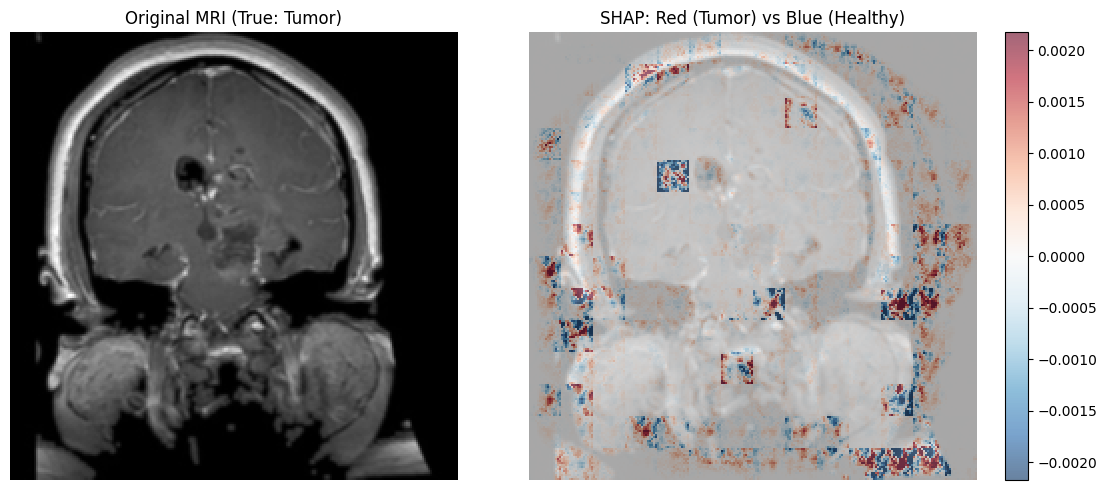

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import shap

def run_shap_explanation(model, X_test, y_test_raw, device, background_samples=8):
    class_names = ['No Tumor', 'Tumor']

    # 1. Prepare Model State
    model.eval()
    torch.backends.cudnn.enabled = False

    print("🚀 Starting SHAP analysis (GradientExplainer)...")

    # 2. Prepare Data
    background = torch.from_numpy(X_test[:background_samples]).float().to(device)

    # Select a Tumor sample for the explanation
    tumor_indices = np.where(y_test_raw == 1)[0]
    idx = tumor_indices[0] if len(tumor_indices) > 0 else 0
    test_image = torch.from_numpy(X_test[idx:idx+1]).float().to(device)

    # 3. Compute SHAP
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(test_image, nsamples=50)

    # 4. FIX: Handle the (224, 224, 2) shape
    # We slice index 1 because that represents the "Tumor" class impact.
    if isinstance(shap_values, list):
        # Format: list of [array(N, C, H, W)]
        s_val = shap_values[1][0]
    else:
        # Format: array(N, C, H, W, 2) or array(N, H, W, 2)
        # We take index 1 from the very last dimension
        s_val = shap_values[0, ..., 1]

    # Ensure we have a 2D (H, W) array for plotting
    if s_val.ndim == 3:  # If (C, H, W)
        shap_2d = np.mean(s_val, axis=0)
    else:
        shap_2d = s_val

    # Prepare grayscale MRI background
    mri_2d = test_image[0].cpu().numpy().mean(axis=0)

    # 5. Plotting (TA Style: Red=Tumor, Blue=Healthy)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original Image
    axes[0].imshow(mri_2d, cmap='gray')
    axes[0].set_title(f"Original MRI (True: {class_names[y_test_raw[idx]]})")
    axes[0].axis('off')

    # SHAP Heatmap Overlay
    # RdBu_r makes positive values Red and negative values Blue
    limit = np.nanpercentile(np.abs(shap_2d), 99)
    axes[1].imshow(mri_2d, cmap='gray', alpha=0.8) # Base MRI
    heatmap = axes[1].imshow(shap_2d, cmap='RdBu_r', alpha=0.6, vmin=-limit, vmax=limit)
    axes[1].set_title("SHAP: Red (Tumor) vs Blue (Healthy)")
    axes[1].axis('off')

    plt.colorbar(heatmap, ax=axes[1])
    plt.tight_layout()
    plt.show()

    # Cleanup
    del background, test_image, shap_values, explainer
    torch.cuda.empty_cache()

# Run the explanation
run_shap_explanation(model, X_test, y_test_raw, device)